In [334]:
import pandas as pd
import numpy as np
import os
import torch
import pytz
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.metrics import mean_squared_error

from darts import TimeSeries
from darts.models import RNNModel

from darts.metrics import mape, mse
from darts.dataprocessing.transformers import Scaler
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
from sqlalchemy.exc import SQLAlchemyError

import warnings
import logging
import pytorch_lightning as pl

# Disable pin_memory warning on MPS
warnings.filterwarnings("ignore", message=".*pin_memory.*MPS.*")

# Disable PyTorch Lightning hardware logs
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

from dotenv import load_dotenv

# Load environment variables
load_dotenv(dotenv_path='../src/.env')

DB_SECRET = os.getenv('DB_SECRET')
DB_HOSTNAME = os.getenv('DB_HOSTNAME')
DB_PORT = int(os.getenv('DB_PORT'))
DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')


In [335]:
def device_check():
    if torch.backends.mps.is_available():
        return torch.device("mps"), True
    elif torch.cuda.is_available():
        return torch.device("cuda"), False
    else:
        return torch.device("cpu"), False

device, force_float32 = device_check()
device, force_float32


(device(type='mps'), True)

In [337]:
def load_data(metric_name):
    engine = create_engine(
        f'postgresql+psycopg2://{DB_USER}:{DB_SECRET}@{DB_HOSTNAME}:{DB_PORT}/{DB_NAME}'
    )
    query = text(f"SELECT * FROM input WHERE metric_name = '{metric_name}'")

    with engine.connect() as conn:
        df = pd.read_sql(query, conn)

    print(f"Loaded {len(df)} records.")
    return df

metric_name = "cpu_usage_upf"
df_raw = load_data(metric_name)
df_raw.head()


Loaded 15328 records.


,metric_name,value,datetime
0,cpu_usage_upf,0.000128,2025-11-25 00:01:15+00:00
1,cpu_usage_upf,0.000120,2025-11-25 00:01:30+00:00
2,cpu_usage_upf,0.000109,2025-11-25 00:01:45+00:00
3,cpu_usage_upf,0.000103,2025-11-25 00:02:00+00:00
4,cpu_usage_upf,0.000120,2025-11-25 04:23:15+00:00


In [342]:
def data_transformation(df, frequency):
    df_pivot = df.pivot_table(
        index='datetime', 
        columns='metric_name', 
        values='value'
    )

    df_resampled = (
        df_pivot
        .reset_index()
        .resample(frequency, on="datetime")
        .max()
        .interpolate()
    )

    df_resampled.index = df_resampled.index.tz_localize(None)
    return df_resampled

frequency = "1T"
df_resampled = data_transformation(df_raw, frequency)
df_resampled.head()


/var/folders/vr/sg92rdxs1cq_7f1s1jhpw2dh0000gn/T/ipykernel_75599/2830608082.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample(frequency, on="datetime")


metric_name,cpu_usage_upf
datetime,
2025-11-23 00:01:00,0.000132
2025-11-23 00:02:00,0.000129
2025-11-23 00:03:00,0.000126
2025-11-23 00:04:00,0.000121
2025-11-23 00:05:00,0.000130


In [343]:
# compute statistics
mean = df_resampled['cpu_usage_upf'].mean()
std = df_resampled['cpu_usage_upf'].std()
var = df_resampled['cpu_usage_upf'].var()

cv = std / mean   # coefficient of variation

print("Mean:", mean)
print("Std:", std)
print("Variance:", var)
print("Coefficient of Variation:", cv)

Mean: 0.00013140199146406372
Std: 1.3766477932238293e-05
Variance: 1.895159146588039e-10
Coefficient of Variation: 0.1047661285712188


In [344]:
def split_dataset(df):
    train_size = int(0.7 * len(df))
    split_point = df.iloc[train_size].name

    series = TimeSeries.from_dataframe(df.reset_index(), "datetime")

    train, test = series.split_after(split_point)
    print(f"Train: {len(train)}, Test: {len(test)}")
    return series, train, test

series, train, test = split_dataset(df_resampled)


Train: 2684, Test: 1149


In [345]:
from sklearn.preprocessing import StandardScaler

def normalize_series(series, train, test):
    scaler = Scaler()

    train_t = scaler.fit_transform(train)
    test_t = scaler.transform(test)
    series_t = scaler.transform(series)

    return series_t, train_t, test_t, scaler

series_t, train_t, test_t, transformer = normalize_series(series, train, test)


In [346]:
series_t.head()

<TimeSeries (DataArray) (datetime: 5, component: 1, sample: 1)> Size: 40B
array([[[0.39677928]],

       [[0.36647654]],

       [[0.34115531]],

       [[0.30003938]],

       [[0.378851  ]]])
Coordinates:
  * datetime   (datetime) datetime64[ns] 40B 2025-11-23T00:01:00 ... 2025-11-...
  * component  (component) object 8B 'cpu_usage_upf'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None

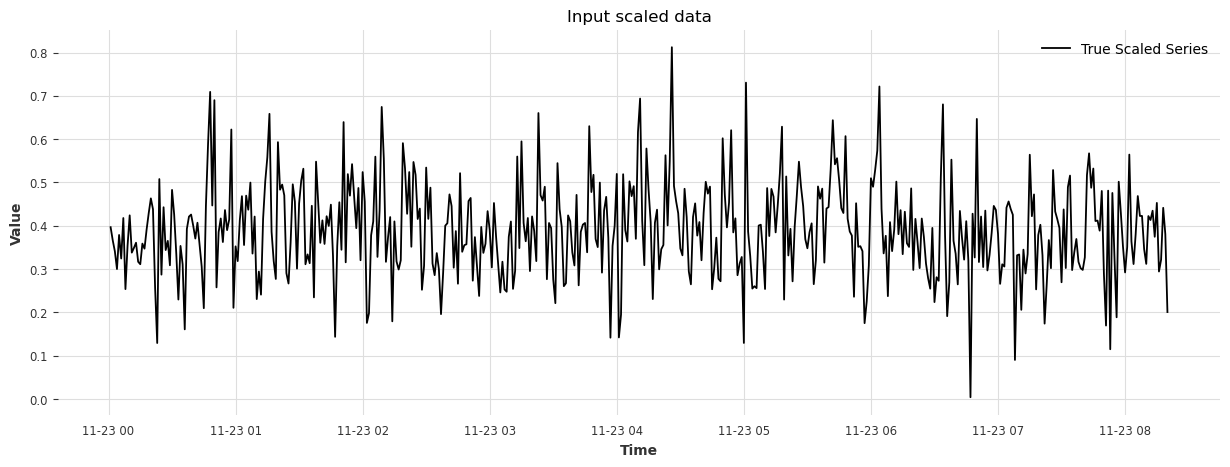

In [348]:
# Plot
plt.figure(figsize=(15,5))
plt.plot(series_t[:500].time_index, series_t[:500].values(), label="True Scaled Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(f"Input scaled data")
plt.legend()
plt.show()

In [379]:
def train_lstm(model_name, train_t, test_t, force_float32):

    if force_float32:
        train_t = train_t.astype(np.float32)
        test_t = test_t.astype(np.float32)

    stopper = EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=0.0001,
        mode="min",
    )

    model = RNNModel(
        model="LSTM",
        hidden_dim=50,
        dropout=0.0,
        batch_size=8,
        n_epochs=100,
        optimizer_kwargs={"lr": 1e-3},
        model_name=model_name,
        log_tensorboard=False,
        random_state=42,
        training_length=12,
        input_chunk_length=6,
        output_chunk_length=1,
        force_reset=True,
        save_checkpoints=True,
        pl_trainer_kwargs={"callbacks": [stopper]},

    )

    model.fit(train_t, val_series=test_t, verbose=True)

    return model


# ---- Run training ----
model_name = "LSTM_cpu_usage_prometheus_local"
my_model = train_lstm(model_name, train_t, test_t, force_float32)


ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.


Sanity Checking: |                                                                                            …

/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:527: Found 3 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

In [366]:
def rolling_forecast_mse(model, train_series, test_series, window=6, force_float32=False):
    if force_float32:
        train_series = train_series.astype(np.float32)
        test_series = test_series.astype(np.float32)

    # start window: last `window` points of training set
    current_window = train_series.tail(window)

    preds = []
    trues = []

    # iterate until we can no longer form a full window
    for i in range(len(test_series)):

        # ---- 1) Predict ----
        pred = model.predict(n=1, series=current_window, verbose=False)
        pred_value = pred.values()[0][0]
        preds.append(pred_value)

        # ---- 2) Store true value ----
        true_value = test_series[i].values()[0]
        trues.append(true_value)

        # ---- 3) Build the new window ----
        # take the next true point (always a TimeSeries object)
        new_point = test_series[i]

        # shift left + append new_time_point
        current_window = current_window[1:].append(new_point)

    # ---- 4) MSE ----
    return trues, preds, mean_squared_error(trues, preds)


In [372]:
trues, preds, mse_score = rolling_forecast_mse(
    model=my_model,
    train_series=train_t,
    test_series=test_t,
    window=12,
    force_float32=force_float32
)
print("Rolling 1-step MSE:", mse_score)


Rolling 1-step MSE: 0.01411469669819388


In [374]:
print("true", np.array(trues[:10]).ravel())
print("pred", np.array(preds[:10]))

true [0.27963018 0.5373601  0.29109713 0.21176551 0.6162262  0.25779948
 0.42691553 0.1171743  0.35177454 0.36490077]
pred [0.3913406  0.37246138 0.41895592 0.37310743 0.36284322 0.43457484
 0.36637378 0.3989209  0.34702194 0.38926548]


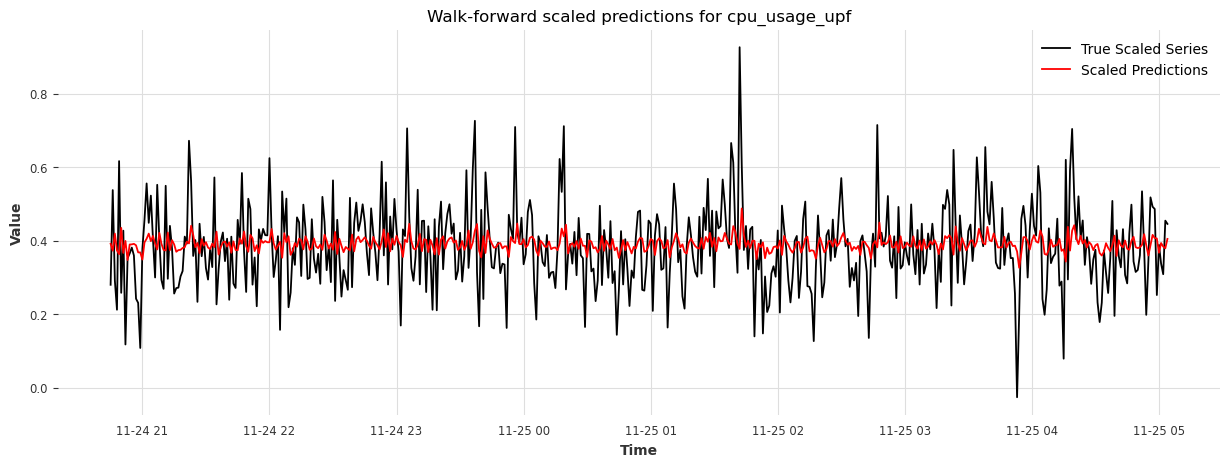

In [373]:
plt.figure(figsize=(15,5))
plt.plot(test_t[:500].time_index, trues[:500], label="True Scaled Series")
plt.plot(test_t[:500].time_index, preds[:500], label="Scaled Predictions", color='red')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(f"Walk-forward scaled predictions for {metric_name}")
plt.legend()
plt.show()

In [354]:
trues_inv = transformer.inverse_transform(TimeSeries.from_values(pd.DataFrame(trues)))
preds_inv = transformer.inverse_transform(TimeSeries.from_values(pd.DataFrame(preds)))
preds_inv.head()

<TimeSeries (DataArray) (time: 5, component: 1, sample: 1)> Size: 20B
array([[[0.00013218]],

       [[0.00012992]],

       [[0.00013557]],

       [[0.00013016]],

       [[0.00012868]]], dtype=float32)
Coordinates:
  * time       (time) int64 40B 0 1 2 3 4
  * component  (component) <U1 4B '0'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None

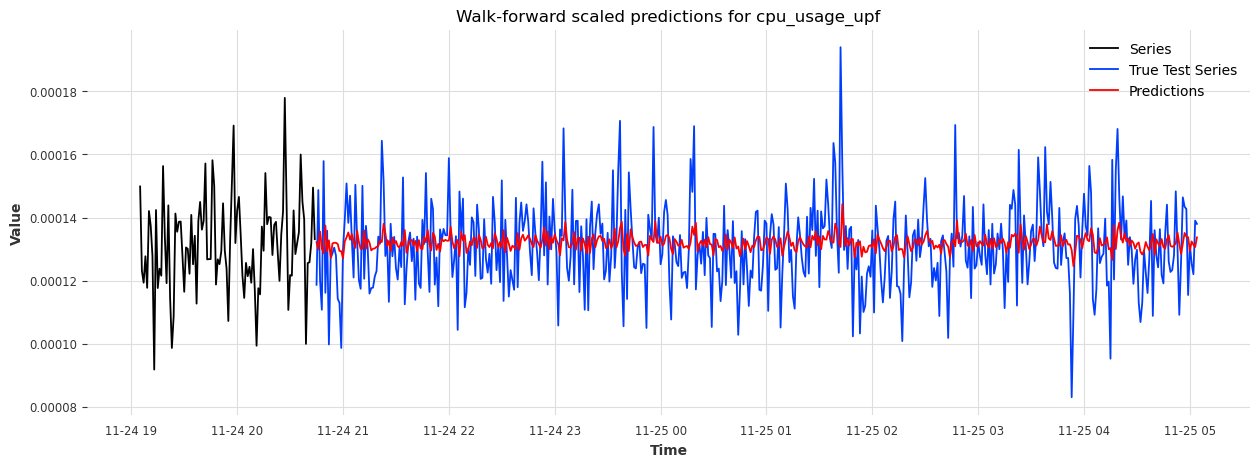

In [359]:
plt.figure(figsize=(15,5))
plt.plot(train[-100:].time_index, train[-100:].values(), label="Series")
plt.plot(test[:500].time_index, trues_inv[:500].values(), label="True Test Series")
plt.plot(test[:500].time_index, preds_inv[:500].values(), label="Predictions", color='red')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(f"Walk-forward scaled predictions for {metric_name}")
plt.legend()
plt.show()